In [11]:
import sys

print(sys.executable)

c:\Users\sh\E-Commerece-Recommendation-System-Machine-Learning-Product-Recommendation-system\.venv\Scripts\python.exe


In [12]:
!{sys.executable} -m pip install xgboost

In [2]:
from xgboost import XGBClassifier

In [4]:
import sys
!{sys.executable} -m pip install catboost

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 1.5 MB/s eta 0:01:06
   ---------------------------------------- 0.5/100.2 MB 1.5 MB/s eta 0:01:06
   ---------------------------------------- 1.0/100.2 MB 1.1 MB/s eta 0:01:29
    --------------------------------------- 1.3/100.2 MB 1.2 MB/s eta 0:01:22
    --------------------------------------- 1.6/100.2 MB 1.2 MB/s eta 0:01:22
    --------------------------------------- 1.8/100.2 MB 1.3 MB/s eta 0:01:18
    --------------------------------------- 2.4/100.2 MB 1.3 MB/s eta 0:01:13
   - -------------------------------------- 2.6/100.2 MB 1.4 MB/s eta 0:01:10
   - -------------------------------------- 3.1/100.2 MB 1.5 MB/s eta 0:01:06
   - -----------------

In [6]:
import sys
!{sys.executable} -m pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 578.7 kB/s eta 0:00:02
   --------------- ------------------------ 0.5/1.4 MB 578.7 kB/s eta 0:00:02
   ----------------------- ---------------- 0.8/1.4 MB 532.3 kB/s eta 0:00:02
   ------------------------------ --------- 1.0/1.4 MB 645.1 kB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 764.0 kB/s  0:00:01


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\sh\Customer-Segmentation-Retention-Analysis\data\Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df["gender"].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [7]:
df.drop("customerID" , axis = 1 , inplace =True)

In [8]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(22)

In [10]:
np.int64(22).item()

22

In [11]:
df.drop_duplicates(inplace = True)

In [12]:
df.duplicated().sum().item()

0

In [13]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df["TotalCharges"].value_counts()

TotalCharges
          11
19.75      9
20.2       8
19.9       7
19.65      7
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
6844.5     1
Name: count, Length: 6531, dtype: int64

In [67]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing TotalCharges:", df["TotalCharges"].isna().sum())

Missing TotalCharges: 0


In [68]:
print(df["TotalCharges"])

0      -0.997334
1      -0.176352
2      -0.962766
3      -0.197874
4      -0.943562
          ...   
7038   -0.131763
7039    2.239996
7040   -0.857564
7041   -0.875157
7042    2.011137
Name: TotalCharges, Length: 7021, dtype: float64


In [69]:
def find_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data < lower) | (data > upper)]

    return outliers, lower, upper, Q1, Q3, IQR


# Find Outliers
outliers, lower, upper, Q1, Q3, IQR = find_outliers(df["TotalCharges"])




In [70]:
cat_columns = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "Churn"
]

In [71]:
from sklearn.preprocessing import LabelEncoder

encode = LabelEncoder()

for i in cat_columns:
    df[i] = encode.fit_transform(df[i])

In [72]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,-1.164135,-0.997334,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,-0.262811,-0.176352,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,-0.365914,-0.962766,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,-0.750058,-0.197874,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,0.194503,-0.943562,1


In [73]:
df["Churn"].value_counts()

Churn
0    5164
1    1857
Name: count, dtype: int64

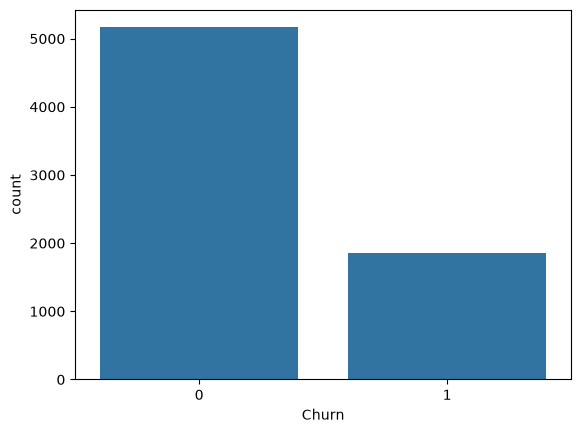

In [74]:
sns.countplot(data = df , x = "Churn")
plt.show()

In [75]:
import  pandas as pd
x = df.drop("Churn" , axis = 1)
y = df["Churn"]

In [24]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [76]:
from sklearn.model_selection import train_test_split

In [77]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)



In [78]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,-1.164135,-0.997334,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,-0.262811,-0.176352,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,-0.365914,-0.962766,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,-0.750058,-0.197874,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,0.194503,-0.943562,1


# Imbalance data

In [79]:

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train , y_train = smote.fit_resample(x_train , y_train)

In [80]:
y_train.value_counts()

Churn
1    4111
0    4111
Name: count, dtype: int64

In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [50]:
df[["MonthlyCharges", "TotalCharges"]] = scaler.fit_transform(
    df[["MonthlyCharges", "TotalCharges"]]
)

In [85]:
models = {

    'Logistic Regression Model': LogisticRegression(max_iter=1000),

    'SVC Model': SVC(kernel='rbf', C=1.0),

    'KNN Model': KNeighborsClassifier(n_neighbors=5),

    'Decision Tree Model': DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),

    'Random Forest Model': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),

    'Adaboost Model': AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.05,
        random_state=42
    ),

    'Xgboost Model': XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ),

    'Catboost Model': CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=False,
        random_seed=42
    ),

    'LightGBM Model': lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=20,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1
    )
}

In [86]:
# fucntion to evaluate model
def evaluate_model(true , predicted):
    report =classification_report(true , predicted)
    score = accuracy_score(true , predicted)
    return report , score

In [87]:
models_list = []
test_scores = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    #model ---> fit
    model.fit(x_train, y_train)

    #prediction
    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    #evaluate model
    train_report, train_accuray = evaluate_model(y_train, train_pred)
    test_report, test_accuracy = evaluate_model(y_test, test_pred)

    print(list(models.keys())[i])
    models_list.append(list(models.keys())[i])

    print('Model Train Performance:')
    print(train_report)
    print('Model Test Performance:')
    print(test_report)

    print('-----------------------------')
    test_scores.append(test_accuracy)

Logistic Regression Model
Model Train Performance:
              precision    recall  f1-score   support

           0       0.82      0.75      0.79      4111
           1       0.77      0.84      0.80      4111

    accuracy                           0.79      8222
   macro avg       0.80      0.79      0.79      8222
weighted avg       0.80      0.79      0.79      8222

Model Test Performance:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1053
           1       0.49      0.78      0.60       352

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.70      1405
weighted avg       0.80      0.74      0.76      1405

-----------------------------
SVC Model
Model Train Performance:
              precision    recall  f1-score   support

           0       0.79      0.75      0.77      4111
           1       0.76      0.80      0.78      4111

    accuracy                           0.7

In [54]:
scores_df = pd.DataFrame(list(zip(models_list , test_scores)), 
columns = ["Model" , "Test Accuracy"]).sort_values(by = "Test Accuracy" , ascending = False)

In [55]:
scores_df

,Model,Test Accuracy
4,Random Forest Model,0.777224
8,LightGBM Model,0.773665
7,Catboost Model,0.766548
6,Xgboost Model,0.756584
0,Logistic Regression Model,0.754448
5,Adaboost Model,0.741637
3,Decision Tree Model,0.738790
2,KNN Model,0.692527
1,SVC Model,0.685409


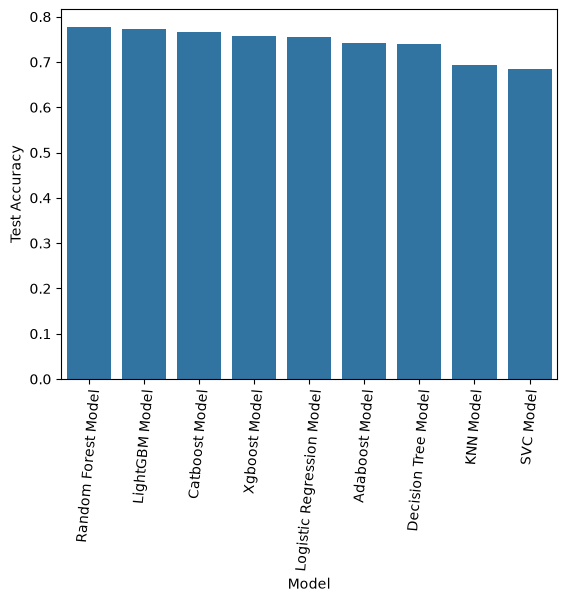

In [56]:
sns.barplot(data = scores_df , x = "Model" , y = "Test Accuracy")
plt.xticks(rotation = 85)
plt.show()

In [57]:
xgb_model = XGBClassifier()
xgb_params = {
    "n_estimators": [8 , 10 , 15 , 50 , 100 , 110],
    "max_depth": [5 , 7 , 9 , 10 , 11],
    "learning_rate": [0.1 , 0.2 , 0.3],
    "sub_samples": [0.8, 1.0]
    }

In [58]:
xgb_grid = GridSearchCV(xgb_model , xgb_params , scoring = 'accuracy' , cv = 5 , verbose = 1 , n_jobs = -1)

In [59]:
xgb_grid.fit(x_train, y_train)

print(xgb_grid.best_params_)
print(xgb_grid.best_score_)

Fitting 5 folds for each of 180 candidates, totalling 900 fits
{'learning_rate': 0.3, 'max_depth': 10, 'n_estimators': 110, 'sub_samples': 0.8}
0.8406945769455477


In [60]:
xgb_model = XGBClassifier(learning_rate = 0.3 , max_depth = 10 , n_estimators = 110 , subsamples = 0.8)
xgb_model.fit(x_train , y_train)
y_pred = xgb_model.predict(x_test)
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1053
           1       0.52      0.53      0.53       352

    accuracy                           0.76      1405
   macro avg       0.68      0.69      0.68      1405
weighted avg       0.76      0.76      0.76      1405



In [61]:
cat_model = CatBoostClassifier(verbose= 0)
cat_params = {
    'iterations' : [100, 200],
    'learning_rate' : [0.1, 0.2, 0.3],
    'depth' : [5, 6, 7, 8, 9, 10]
}

In [62]:
grid_cat = GridSearchCV(cat_model, cat_params, cv = 5, verbose = 1, n_jobs= -1)

In [63]:
grid_cat.fit(x_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CatBoostClassifier(verbose=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'depth': [5, 6, ...], 'iterations': [100, 200], 'learning_rate': [0.1, 0.2, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits

In [64]:
print(grid_cat.best_params_)
print(grid_cat.best_score_)

{'depth': 8, 'iterations': 200, 'learning_rate': 0.3}
0.8402078849865772


In [65]:
cat_model = CatBoostClassifier(depth = 8 , iterations = 200 , learning_rate = 0.3)
cat_model.fit(x_train , y_train)
y_pred = cat_model.predict(x_test)
print(classification_report(y_test , y_pred))

0:	learn: 0.5392083	total: 16.1ms	remaining: 3.2s
1:	learn: 0.4697859	total: 33.3ms	remaining: 3.3s
2:	learn: 0.4231395	total: 47ms	remaining: 3.09s
3:	learn: 0.3985289	total: 62.2ms	remaining: 3.05s
4:	learn: 0.3805593	total: 79.1ms	remaining: 3.08s
5:	learn: 0.3719863	total: 90.7ms	remaining: 2.93s
6:	learn: 0.3614039	total: 102ms	remaining: 2.82s
7:	learn: 0.3523033	total: 113ms	remaining: 2.72s
8:	learn: 0.3433482	total: 126ms	remaining: 2.68s
9:	learn: 0.3347668	total: 139ms	remaining: 2.64s
10:	learn: 0.3305718	total: 149ms	remaining: 2.56s
11:	learn: 0.3302307	total: 156ms	remaining: 2.44s
12:	learn: 0.3252165	total: 167ms	remaining: 2.4s
13:	learn: 0.3200295	total: 178ms	remaining: 2.37s
14:	learn: 0.3180375	total: 189ms	remaining: 2.33s
15:	learn: 0.3134615	total: 199ms	remaining: 2.29s
16:	learn: 0.3080620	total: 210ms	remaining: 2.26s
17:	learn: 0.3042354	total: 223ms	remaining: 2.26s
18:	learn: 0.3019927	total: 236ms	remaining: 2.25s
19:	learn: 0.2988109	total: 245ms	remain